# KV Cache Benchmark

Compares per-decode-step cost with and without a KV cache at sequence
lengths 128, 512, and 2048. Numbers come from `01_kv_cache/results.csv`,
produced by `01_kv_cache/benchmark.py`.

Reproduce the numbers:
    uv run 01_kv_cache/benchmark.py

In [1]:
import pandas as pd

df = pd.read_csv("../01_kv_cache/results.csv")
df

,seq_len,prefill_ms,decode_naive_ms,decode_cached_ms,speedup
0,128,19.239094,19.239094,4.891006,3.933566
1,512,105.939140,105.939140,7.051957,15.022658
2,2048,1082.116978,1082.116978,17.022859,63.568463


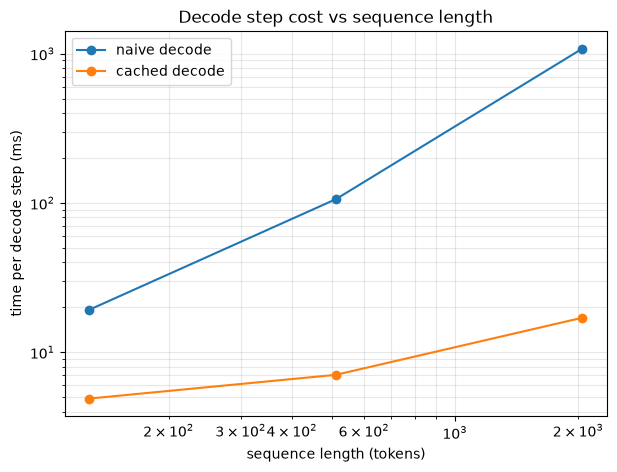

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(df["seq_len"], df["decode_naive_ms"], "o-", label="naive decode")
ax.plot(df["seq_len"], df["decode_cached_ms"], "o-", label="cached decode")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("sequence length (tokens)")
ax.set_ylabel("time per decode step (ms)")
ax.set_title("Decode step cost vs sequence length")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.show()

## What this shows

**Speedup grows with sequence length.** 3.9× at 128 tokens, 63.6× at 2048.
Naive decoding is O(L²) per step in attention; caching makes it O(L).

**Cached decode has a constant floor (~4 ms).** This is the per-step cost
of MLP, LayerNorms, and sampling — independent of sequence length. With
concurrent requests, this floor is what batching amortizes. See
Milestone 2.

**The cache costs memory.** 2 × n_layer × n_head × head_dim × L × dtype
bytes ≈ 37.7 MB per sequence at L=2048, fp32. Linear in sequence length
and concurrency. See Milestone 3.

Full writeup: see `README.md` § "KV cache".